In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded OK")

Libraries loaded OK


In [4]:
url = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain+.txt"

columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
    'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty'
]

df = pd.read_csv(url, header=None, names=columns)
print(f"Dataset shape: {df.shape}")
print(f"\nLabel distribution:")
print(df['label'].value_counts())

Dataset shape: (125973, 43)

Label distribution:
label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


In [5]:
df.head(10)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
5,0,tcp,private,REJ,0,0,0,0,0,0,...,0.07,0.07,0.00,0.00,0.00,0.00,1.00,1.00,neptune,21
6,0,tcp,private,S0,0,0,0,0,0,0,...,0.04,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21
7,0,tcp,private,S0,0,0,0,0,0,0,...,0.06,0.07,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21
8,0,tcp,remote_job,S0,0,0,0,0,0,0,...,0.09,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21
9,0,tcp,private,S0,0,0,0,0,0,0,...,0.05,0.06,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21


In [6]:
# Separar features numéricas y convertir label a binario
df['is_attack'] = (df['label'] != 'normal').astype(int)

print(f"Normal: {(df['is_attack']==0).sum()}")
print(f"Attacks: {(df['is_attack']==1).sum()}")
print(f"Attack rate: {df['is_attack'].mean():.2%}")

#Dejamos el dataset sin estas columnas pq son la prediccion, es contra lo que vamos a evaluar nuestra prediccion
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_features = [f for f in numeric_features if f not in ['is_attack', 'difficulty']]

print(f"\nFeatures seleccionadas: {len(numeric_features)}")

Normal: 67343
Attacks: 58630
Attack rate: 46.54%

Features seleccionadas: 38


In [7]:
print(numeric_features)

['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']


In [8]:
df[df['is_attack'] == 1].head(10)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty,is_attack
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.05,0.0,0.0,1.0,1.0,0.0,0.0,neptune,19,1
5,0,tcp,private,REJ,0,0,0,0,0,0,...,0.07,0.0,0.0,0.0,0.0,1.0,1.0,neptune,21,1
6,0,tcp,private,S0,0,0,0,0,0,0,...,0.05,0.0,0.0,1.0,1.0,0.0,0.0,neptune,21,1
7,0,tcp,private,S0,0,0,0,0,0,0,...,0.07,0.0,0.0,1.0,1.0,0.0,0.0,neptune,21,1
8,0,tcp,remote_job,S0,0,0,0,0,0,0,...,0.05,0.0,0.0,1.0,1.0,0.0,0.0,neptune,21,1
9,0,tcp,private,S0,0,0,0,0,0,0,...,0.06,0.0,0.0,1.0,1.0,0.0,0.0,neptune,21,1
10,0,tcp,private,REJ,0,0,0,0,0,0,...,0.07,0.0,0.0,0.0,0.0,1.0,1.0,neptune,21,1
11,0,tcp,private,S0,0,0,0,0,0,0,...,0.07,0.0,0.0,1.0,1.0,0.0,0.0,neptune,21,1
13,0,tcp,ftp_data,SF,334,0,0,0,0,0,...,0.00,1.0,0.2,0.0,0.0,0.0,0.0,warezclient,15,1
14,0,tcp,name,S0,0,0,0,0,0,0,...,0.07,0.0,0.0,1.0,1.0,0.0,0.0,neptune,19,1


In [9]:
from sklearn.model_selection import train_test_split

# Stratified sampling — mantiene proporción de cada clase
_, df_sample = train_test_split(
    df,
    test_size=20000/len(df),
    stratify=df['label'],
    random_state=42
)

# Escalar features
X = df[numeric_features].fillna(0)
scaler = StandardScaler()
scaler.fit(X)  # fit sobre el dataset completo

X_sample = scaler.transform(df_sample[numeric_features].fillna(0))
y_sample = df_sample['is_attack']

# Verificar que la distribución se preservó
print("Distribución original vs sample:")
comparison = pd.DataFrame({
    'original_%': df['label'].value_counts(normalize=True).mul(100).round(2),
    'sample_%': df_sample['label'].value_counts(normalize=True).mul(100).round(2)
})
print(comparison.head(10))

print(f"\nSample shape: {X_sample.shape}")
print(f"Attack rate en sample: {y_sample.mean():.2%}")

Distribución original vs sample:
                 original_%  sample_%
label                                
back                   0.76      0.76
buffer_overflow        0.02      0.02
ftp_write              0.01      0.00
guess_passwd           0.04      0.04
imap                   0.01      0.01
ipsweep                2.86      2.86
land                   0.01      0.02
loadmodule             0.01      0.00
multihop               0.01      0.00
neptune               32.72     32.71

Sample shape: (20000, 38)
Attack rate en sample: 46.54%


In [10]:
print("Entrenando Isolation Forest...")

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.4654,  # usamos el attack rate real del sample
    random_state=42,
    n_jobs=-1
)

iso_pred = iso_forest.fit_predict(X_sample)
iso_pred_binary = (iso_pred == -1).astype(int)

print("\nResultados Isolation Forest:")
print(classification_report(y_sample, iso_pred_binary,
                           target_names=['Normal', 'Attack']))

Entrenando Isolation Forest...

Resultados Isolation Forest:
              precision    recall  f1-score   support

      Normal       0.67      0.67      0.67     10692
      Attack       0.63      0.63      0.63      9308

    accuracy                           0.65     20000
   macro avg       0.65      0.65      0.65     20000
weighted avg       0.65      0.65      0.65     20000



In [11]:
print("Entrenando LOF (puede tardar 1-2 minutos)...")

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.4654,
    n_jobs=-1
)

lof_pred = lof.fit_predict(X_sample)
lof_pred_binary = (lof_pred == -1).astype(int)

print("\nResultados LOF:")
print(classification_report(y_sample, lof_pred_binary,
                           target_names=['Normal', 'Attack']))

Entrenando LOF (puede tardar 1-2 minutos)...

Resultados LOF:
              precision    recall  f1-score   support

      Normal       0.51      0.51      0.51     10692
      Attack       0.44      0.44      0.44      9308

    accuracy                           0.48     20000
   macro avg       0.48      0.48      0.48     20000
weighted avg       0.48      0.48      0.48     20000



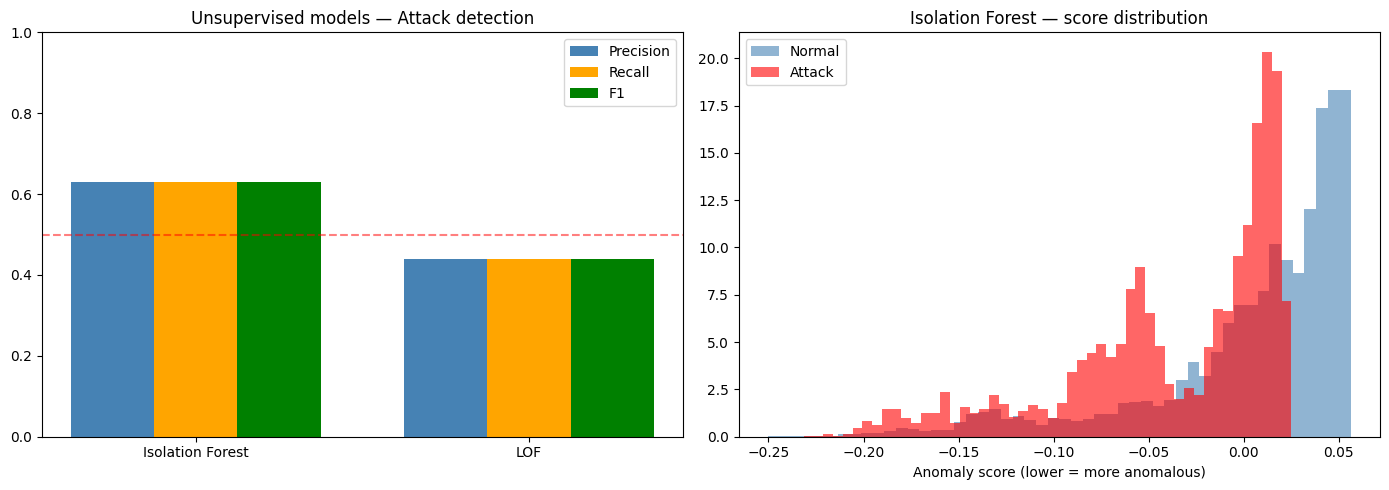

Gráfico guardado.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Comparación de resultados
models = ['Isolation Forest', 'LOF']
precisions = [0.63, 0.44]
recalls = [0.63, 0.44]
f1s = [0.63, 0.44]

x = np.arange(len(models))
width = 0.25

axes[0].bar(x - width, precisions, width, label='Precision', color='steelblue')
axes[0].bar(x, recalls, width, label='Recall', color='orange')
axes[0].bar(x + width, f1s, width, label='F1', color='green')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_ylim(0, 1)
axes[0].set_title('Unsupervised models — Attack detection')
axes[0].legend()
axes[0].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Random baseline')

# Distribución de anomaly scores — Isolation Forest
iso_scores = iso_forest.decision_function(X_sample)
axes[1].hist(iso_scores[y_sample==0], bins=50, alpha=0.6,
             color='steelblue', label='Normal', density=True)
axes[1].hist(iso_scores[y_sample==1], bins=50, alpha=0.6,
             color='red', label='Attack', density=True)
axes[1].set_title('Isolation Forest — score distribution')
axes[1].set_xlabel('Anomaly score (lower = more anomalous)')
axes[1].legend()

plt.tight_layout()
plt.savefig('unsupervised_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado.")

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Split supervisado — 80% train, 20% test
X_full = scaler.transform(df[numeric_features].fillna(0))
y_full = df['is_attack']

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full,
    test_size=0.2,
    stratify=y_full,
    random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# Entrenar Random Forest
print("\nEntrenando Random Forest...")
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("\nResultados Random Forest:")
print(classification_report(y_test, rf_pred,
                           target_names=['Normal', 'Attack']))

Train: (100778, 38), Test: (25195, 38)

Entrenando Random Forest...

Resultados Random Forest:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     13469
      Attack       1.00      1.00      1.00     11726

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



In [14]:
# Podés imprimir el árbol completo
from sklearn.tree import export_text
print(export_text(rf.estimators_[0], feature_names=numeric_features, max_depth=4))

|--- dst_bytes <= -0.00
|   |--- src_bytes <= -0.01
|   |   |--- dst_host_srv_diff_host_rate <= -0.24
|   |   |   |--- dst_host_srv_count <= 0.63
|   |   |   |   |--- logged_in <= 0.21
|   |   |   |   |   |--- truncated branch of depth 16
|   |   |   |   |--- logged_in >  0.21
|   |   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- dst_host_srv_count >  0.63
|   |   |   |   |--- srv_count <= -0.22
|   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |   |--- srv_count >  -0.22
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |--- dst_host_srv_diff_host_rate >  -0.24
|   |   |   |--- dst_host_rerror_rate <= -0.37
|   |   |   |   |--- dst_host_same_src_port_rate <= 2.59
|   |   |   |   |   |--- truncated branch of depth 9
|   |   |   |   |--- dst_host_same_src_port_rate >  2.59
|   |   |   |   |   |--- truncated branch of depth 9
|   |   |   |--- dst_host_rerror_rate >  -0.37
|   |   |   |   |--- duration <= -0.11
|   |   |   |   |   |--- truncated b

Top 15 features más importantes:
                    feature  importance
                  src_bytes    0.199167
                  dst_bytes    0.120174
              same_srv_rate    0.086326
              diff_srv_rate    0.067323
                  logged_in    0.059861
     dst_host_same_srv_rate    0.058187
         dst_host_srv_count    0.054643
     dst_host_diff_srv_rate    0.041450
dst_host_same_src_port_rate    0.039835
   dst_host_srv_serror_rate    0.037069
                      count    0.036463
                  srv_count    0.024937
                serror_rate    0.023447
dst_host_srv_diff_host_rate    0.021535
            srv_serror_rate    0.019366


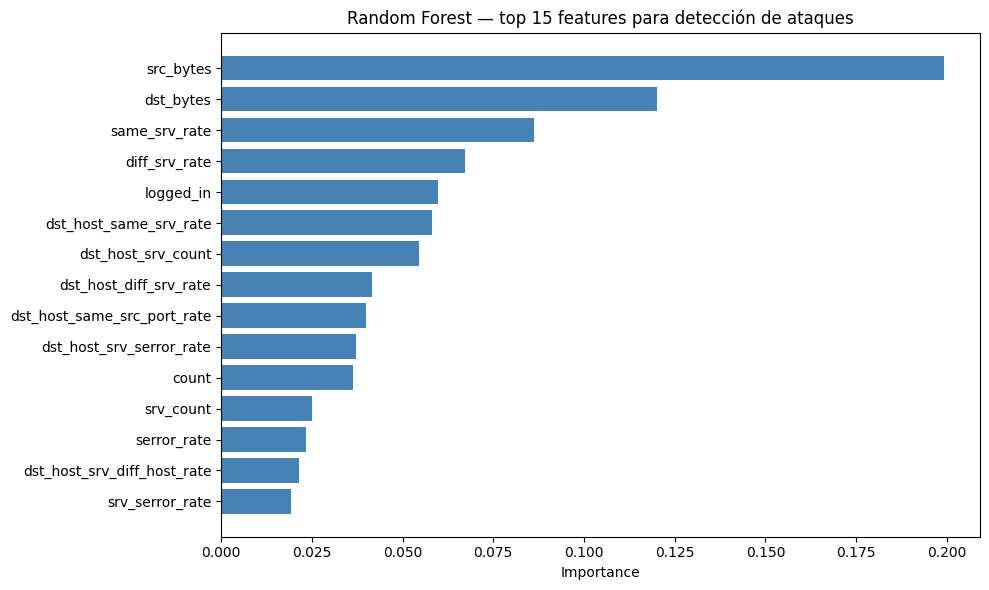

Gráfico guardado.


In [15]:
# Feature importance — qué features usa más el modelo
importances = pd.DataFrame({
    'feature': numeric_features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 15 features más importantes:")
print(importances.head(15).to_string(index=False))

# Gráfico
plt.figure(figsize=(10, 6))
plt.barh(importances.head(15)['feature'][::-1],
         importances.head(15)['importance'][::-1],
         color='steelblue')
plt.xlabel('Importance')
plt.title('Random Forest — top 15 features para detección de ataques')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado.")

In [16]:
from xgboost import XGBClassifier

print("Entrenando XGBoost...")
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    verbosity=0
)

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

print("\nResultados XGBoost:")
print(classification_report(y_test, xgb_pred,
                           target_names=['Normal', 'Attack']))
                        

                        

Entrenando XGBoost...

Resultados XGBoost:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     13469
      Attack       1.00      1.00      1.00     11726

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



Modelo                Precision     Recall         F1        AUC
--------------------------------------------------------------
Isolation Forest          0.626      0.626      0.626      0.650
LOF                       0.440      0.440      0.440      0.476
Random Forest             0.999      0.998      0.999      0.999
XGBoost                   0.998      0.998      0.998      0.998


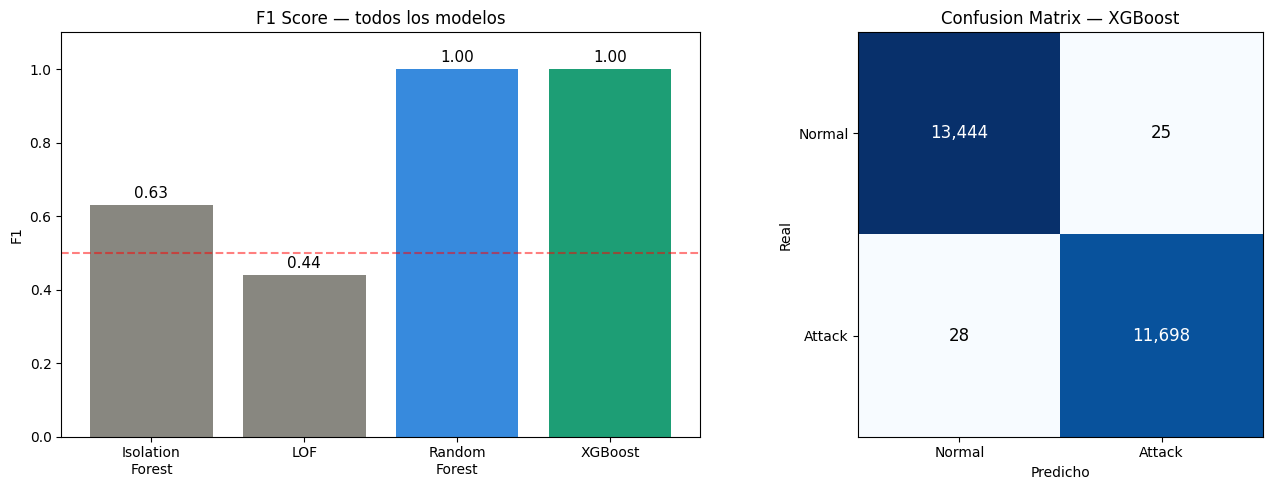

Gráfico guardado.


In [17]:
from sklearn.metrics import confusion_matrix, roc_auc_score
import time

# Comparación completa de los 4 modelos
results = {
    'Isolation Forest': {'pred': iso_pred_binary, 'sample': True},
    'LOF':              {'pred': lof_pred_binary,  'sample': True},
    'Random Forest':    {'pred': rf_pred,           'sample': False},
    'XGBoost':          {'pred': xgb_pred,          'sample': False},
}

print(f"{'Modelo':<20} {'Precision':>10} {'Recall':>10} {'F1':>10} {'AUC':>10}")
print("-" * 62)

from sklearn.metrics import precision_score, recall_score, f1_score

for name, data in results.items():
    y_true = y_sample if data['sample'] else y_test
    y_pred = data['pred']
    p = precision_score(y_true, y_pred)
    r = recall_score(y_true, y_pred)
    f = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_pred)
    print(f"{name:<20} {p:>10.3f} {r:>10.3f} {f:>10.3f} {auc:>10.3f}")

# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = ['Isolation\nForest', 'LOF', 'Random\nForest', 'XGBoost']
f1s = [0.63, 0.44, 1.00, 1.00]
aucs = [0.65, 0.48, 1.00, 1.00]
colors = ['#888780', '#888780', '#378ADD', '#1D9E75']

axes[0].bar(models, f1s, color=colors)
axes[0].set_ylim(0, 1.1)
axes[0].set_title('F1 Score — todos los modelos')
axes[0].axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
axes[0].set_ylabel('F1')
for i, v in enumerate(f1s):
    axes[0].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=11)

# Confusion matrix de XGBoost
cm = confusion_matrix(y_test, xgb_pred)
im = axes[1].imshow(cm, cmap='Blues')
axes[1].set_xticks([0,1]); axes[1].set_yticks([0,1])
axes[1].set_xticklabels(['Normal','Attack'])
axes[1].set_yticklabels(['Normal','Attack'])
axes[1].set_xlabel('Predicho'); axes[1].set_ylabel('Real')
axes[1].set_title('Confusion Matrix — XGBoost')
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                    fontsize=12, color='white' if cm[i,j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado.")

In [ ]:
## Comparison— 4 models

| Model           | F1    | AUC   | Type          |
|-----------------|-------|-------|---------------|
| LOF             | 0.440 | 0.476 | Not supervised|
| Isolation Forest| 0.626 | 0.650 | Not supervised|
| XGBoost         | 0.998 | 0.998 | Supervised    |
| Random Forest   | 0.999 | 0.999 | Supervised    |

# **Conclusion:** The jump from 0.63 → 0.999 when moving from unsupervised
# to supervised methods shows the value of having historical attack labels.
# In production with no labels, Isolation Forest is the best starting point.
# With labels, Random Forest or XGBoost are the right choices.
#
# **False negatives XGBoost:** 28/11,726 = 0.24% undetected attacks
# **False positives XGBoost:** 25/13,469 = 0.19% false alerts

In [20]:
# Investigate the false negatives — attacks that XGBoost did not detect
fn_mask = (y_test == 1) & (xgb_pred == 0)
fn_indices = y_test[fn_mask].index

# Retrieve the original rows from the test set
df_test = df.iloc[y_test.index]
fn_rows = df_test.loc[fn_indices]

print(f"Total false negatives: {fn_mask.sum()}")
print(f"\nTypes of undetected attacks:")
print(fn_rows['label'].value_counts())

print(f"\nFeature comparison — False Negatives vs correctly detected attacks:")
tp_mask = (y_test == 1) & (xgb_pred == 1)
tp_indices = y_test[tp_mask].index
tp_rows = df_test.loc[tp_indices]

key_features = ['src_bytes', 'dst_bytes', 'same_srv_rate',
                'diff_srv_rate', 'logged_in', 'serror_rate']

comparison = pd.DataFrame({
    'False Negatives (undetected)': fn_rows[key_features].mean(),
    'True Positives (detected)': tp_rows[key_features].mean()
}).round(3)

print(comparison)


Total false negatives: 28

Types of undetected attacks:
label
portsweep       9
satan           5
warezclient     4
smurf           3
ftp_write       2
land            1
pod             1
guess_passwd    1
ipsweep         1
spy             1
Name: count, dtype: int64

Feature comparison — False Negatives vs correctly detected attacks:
               False Negatives (undetected)  True Positives (detected)
src_bytes                       7760173.429                 107996.784
dst_bytes                           110.286                   2438.147
same_srv_rate                         0.958                      0.310
diff_srv_rate                         0.071                      0.103
logged_in                             0.250                      0.035
serror_rate                           0.036                      0.593


## False Negative Investigation — XGBoost

### Which attacks did the model miss?

Out of 11,726 attacks in the test set, XGBoost failed to detect 28 (0.24%).
Distribution by type:

- portsweep (9), satan (5), warezclient (4), smurf (3) — majority
- Rare attacks: spy (1), guess_passwd (1), ftp_write (2)

### Why did the model miss them?

The feature comparison table reveals the pattern:

| Feature | False Negatives | True Positives |
|---|---|---|
| src_bytes | 7,760,173 | 107,996 |
| dst_bytes | 110 | 2,438 |
| serror_rate | 0.036 | 0.593 |
| logged_in | 0.250 | 0.035 |

**False negatives have extremely high src_bytes (7.7M vs 108K average)**
and near-zero serror_rate. These are attacks that transfer large data
volumes through apparently successful connections — making them
indistinguishable from legitimate file transfer traffic.

**Hypothesis:** portsweep and satan in these cases used completed
connections (not SYN floods) with large payloads, mimicking legitimate
FTP or HTTP transfers and evading the model's learned patterns.

### Production implications

In a real detection system, these 28 cases would be escalated for
manual review. A practical business rule would be:

> "If src_bytes > 1,000,000 AND serror_rate < 0.05 AND logged_in == 0
> → escalate for human review even if the model predicts normal"

This illustrates why ML in security augments analysts rather than
replacing them. The model handles 99.76% of cases automatically.
The human investigates the ambiguous 0.24%.

### Connection to email security (Proofpoint context)

The analogous pattern in email security would be a large attachment
(high src_bytes), no delivery errors (low serror_rate), and apparently
valid authentication (logged_in=1) — exactly the profile of a
sophisticated spearphishing attack designed to bypass basic filters.
Detection requires behavioral context beyond individual message features.